### Deep Learning Module End

In [78]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [79]:
# Loading the dataset

# from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("Feature Shape:",X.shape)
print("Target Shape:",y.shape)
print("Fetaure Columns:",diabetes.feature_names)

Feature Shape: (442, 10)
Target Shape: (442,)
Fetaure Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [80]:
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [81]:
# For Missing Values

df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [83]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


### Exploratory Data Analysis(EDA)

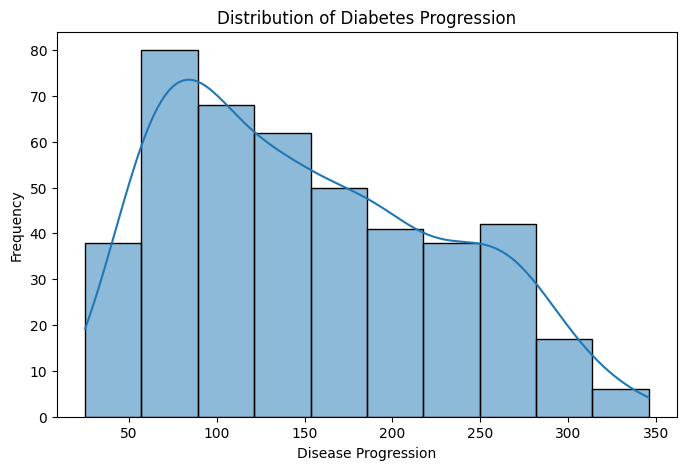

In [84]:
plt.figure(figsize=(8,5))

sns.histplot(df["target"], kde=True)

plt.title("Distribution of Diabetes Progression")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.show()

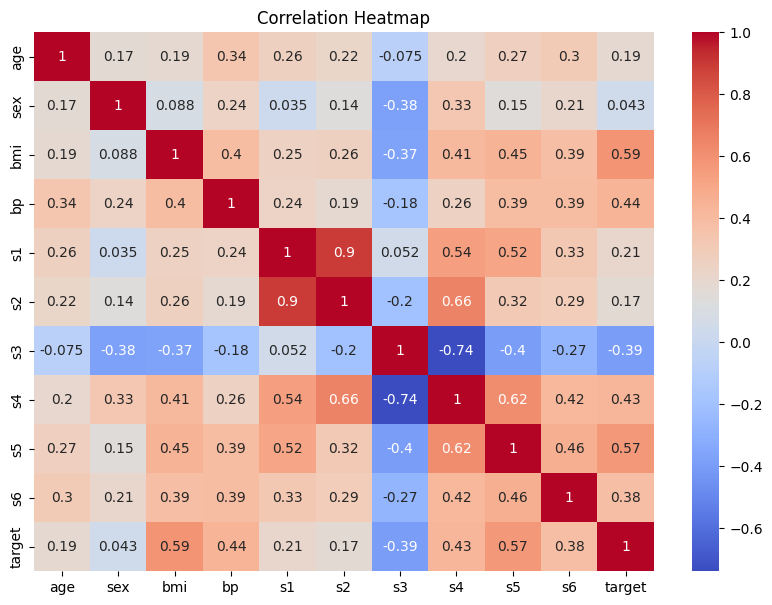

In [85]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

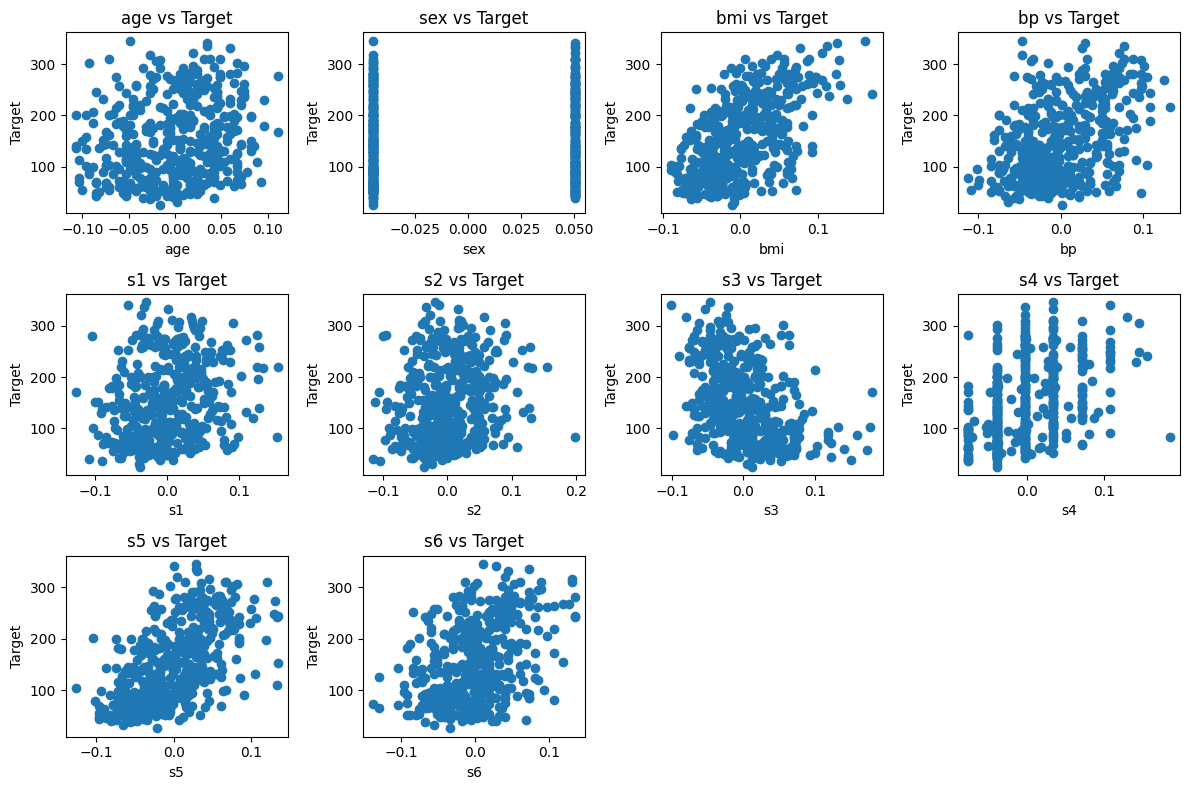

In [86]:
#  Relationships between features and the target variable

plt.figure(figsize=(12,8))

for i, feature in enumerate(diabetes.feature_names):
    plt.subplot(3, 4, i+1)
    plt.scatter(df[feature], df["target"])
    plt.xlabel(feature)
    plt.ylabel("Target")
    plt.title(f"{feature} vs Target")

plt.tight_layout()
plt.show()

In [87]:
# Train Test Splitting

X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size = 0.2,
            random_state= 42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (353, 10)
Test Shape: (89, 10)


In [88]:
# Normalizing The Features

scaler = StandardScaler()

X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.fit_transform(X_test)

### Building the ANN Model

In [89]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_Scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# Compile the model

model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

### Training the ANN Model

In [91]:
history = model.fit(
    X_train_Scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - loss: 31451.2441 - mae: 158.5209 - val_loss: 22381.4434 - val_mae: 133.7804
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 31277.8828 - mae: 157.9839 - val_loss: 22239.9512 - val_mae: 133.2749
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 31074.0000 - mae: 157.3709 - val_loss: 22072.8125 - val_mae: 132.6859
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30823.1348 - mae: 156.6305 - val_loss: 21868.3691 - val_mae: 131.9652
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30509.5098 - mae: 155.7058 - val_loss: 21614.7168 - val_mae: 131.0692
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30103.1836 - mae: 154.5192 - val_loss: 21298.8301 - val_mae: 129.9504
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29605.2051 - mae: 153.0443 - val_loss: 20907.2285 - val_mae: 128.5742
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28971.4219 - mae: 151.1700 - val_loss: 20430.

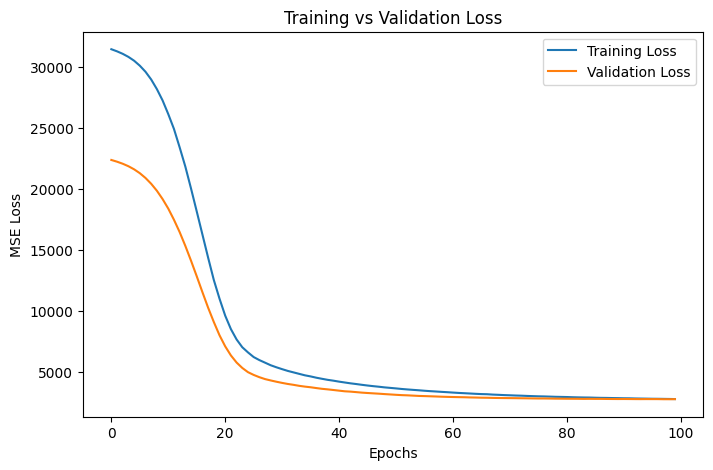

In [92]:
# Plotting Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [93]:
# For Prediction

y_pred = model.predict(X_test_Scaled)

y_pred = y_pred.flatten()

print("Predictions:")
print(y_pred[:10])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predictions:
[171.2635   203.12105  146.89796  354.03806  104.46755  119.37372
 273.64395  187.05501   81.674164  76.342445]


### Evaluating the Model

In [94]:
test_loss, test_mae = model.evaluate(
    X_test_Scaled,
    y_test,
    verbose=0
)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 3146.806884765625
Test MAE: 44.55465316772461


In [95]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-Square Score:", r2)

Mean Squared Error: 3146.8068278608857
Root Mean Squared Error: 56.09640655033873
R-Square Score: 0.4060557384484237


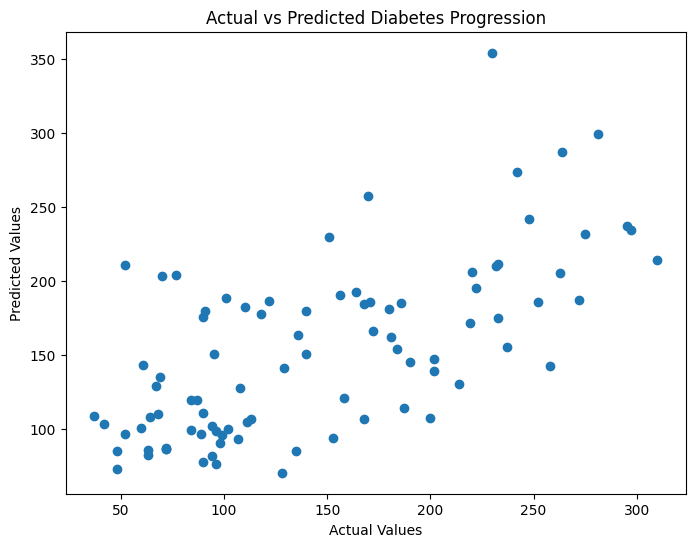

In [96]:
# Plotting the prediction

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Diabetes Progression")

plt.show()

###Improving the Model

In [97]:
from tensorflow.keras.layers import Dropout

improved_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_Scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

# Compiling
improved_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

improved_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
# Training the improved model

improved_history = improved_model.fit(
    X_train_Scaled,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 31270.5742 - mae: 157.8594 - val_loss: 21984.3438 - val_mae: 132.3037
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 30125.0430 - mae: 154.2654 - val_loss: 20435.3906 - val_mae: 126.5107
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 26585.7871 - mae: 143.0515 - val_loss: 16186.4385 - val_mae: 109.4013
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18020.7891 - mae: 111.6982 - val_loss: 8535.2002 - val_mae: 71.5202
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7982.4531 - mae: 70.1811 - val_loss: 3854.2324 - val_mae: 48.3760
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5567.4766 - mae: 58.3046 - val_loss: 3418.9600 - val_mae: 45.2503
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4454.0127 - mae: 52.3589 - val_loss: 3362.3623 - val_mae: 42.9626
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4305.1582 - mae: 51.7020 - val_loss: 3082.9512 - v

In [99]:
# Evaluating

improved_pred = improved_model.predict(X_test_Scaled).flatten()

improved_mse = mean_squared_error(y_test, improved_pred)
improved_rmse = np.sqrt(improved_mse)
improved_r2 = r2_score(y_test, improved_pred)

print("Improved Model MSE:", improved_mse)
print("Improved Model RMSE:", improved_rmse)
print("Improved Model R² Score:", improved_r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Improved Model MSE: 2863.8778533657387
Improved Model RMSE: 53.51521142035915
Improved Model R² Score: 0.4594571863352953


In [100]:
# Compiring the models

results = pd.DataFrame({
    "Model": ["Original ANN", "Improved ANN"],
    "MSE": [mse, improved_mse],
    "RMSE": [rmse, improved_rmse],
    "R2 Score": [r2, improved_r2]
})

results

,Model,MSE,RMSE,R2 Score
0,Original ANN,3146.806828,56.096407,0.406056
1,Improved ANN,2863.877853,53.515211,0.459457


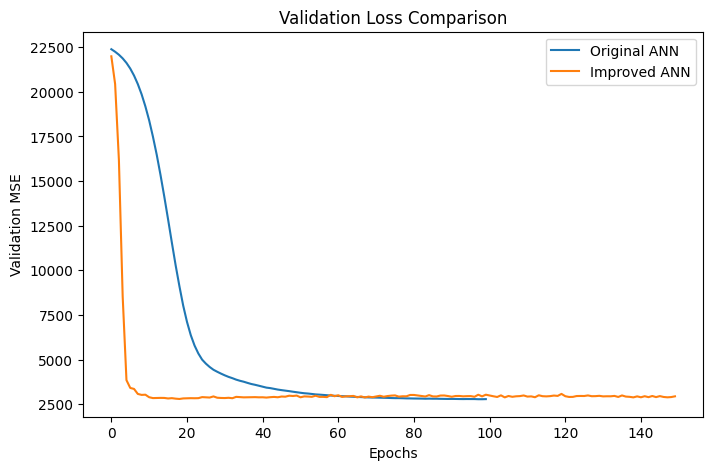

In [101]:
# Visualizing the improvement

plt.figure(figsize=(8,5))

plt.plot(
    history.history["val_loss"],
    label="Original ANN"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Improved ANN"
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation MSE")
plt.legend()

plt.show()

##### The model was improved by adding more neurons and hidden layers, using Dropout, and adjusting the epochs and batch size, which helped the model learn better and improved its prediction performance by reducing error and increasing the R² score.
